<a href="https://colab.research.google.com/github/ddrous/self-mod/blob/main/Illustrating_CSM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%capture
!pip install equinox diffrax

In [ ]:
import jax
import jax.numpy as jnp
# import equinox as eqx

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = 'false'

jax.devices()

[CpuDevice(id=0)]

In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import time

#========  Define smooth function f(x, y)
# def f(y):
#     return jax.nn.softplus(0.0 + 10*y)**2

# def f(theta):
#     return jnp.tanh(theta) + 0.1 * theta**2

# # f now has two layers
# def f(y):
#     l1 = jax.nn.softplus(0.1 + 10*y)
#     l2 = jax.nn.relu(-2.0 + 5*l1)
#     return l2

# def f(y):
#     l1 = jax.nn.softplus(0.1 + 10*y)
#     # l2 = jax.nn.relu(-2.0 + 5*l1)
#     return l1**2


#========  Define sharp function f(x, y)
# def f(theta):
#     return jnp.sin(10 * theta) * jnp.exp(-theta**2 / 2) - 0.1 * theta**4

# 1. Step function
def f(theta):
    return jnp.sign(theta+0.3) + 0.1 * jnp.sin(4*theta+1)

# # 2. Sawtooth function
# def f(theta):
#     return (theta - jnp.floor(theta)) * 2 - 1

# # 3. sine sine wave
# def f(theta):
#     return jnp.sin(0.5+ jnp.sin(5 * theta))

# # # 4. Fractal-like function
# def f(theta):
#     return jnp.sin(theta) + 0.5 * jnp.sin(2*theta) + 0.25 * jnp.sin(4*theta) + 0.125 * jnp.sin(8*theta)

# Define the norm of f(x, y) to be minimized
def norm_f(x, y):
    # return jnp.sqrt(f(x, y)**2)
    f_x = f(x)
    f_y = f(y)
    return jnp.sqrt(f_x**2 + f_y**2)
grad_norm_f = jax.jit(jax.grad(norm_f, argnums=(0, 1)))

def norm_f_taylor(x, y):
    ## now f_x is a taylor expansion at y
    f_x = f(y) + jax.grad(f, argnums=0)(y) * (x - y)
    f_y = f(x) + jax.grad(f, argnums=0)(x) * (y - x)
    return jnp.sqrt(f_x**2 + f_y**2)
grad_norm_f_taylor = jax.jit(jax.grad(norm_f_taylor, argnums=(0, 1)))


# Run gradient descent
learning_rate = 0.1
num_iterations = 25
domain_x = 5.
domain_y = 5.


# Gradient descent function
def gradient_descent(learning_rate, num_iterations, grad_fun, seed=0):
    # Starting coordinates close together
    # x, y = +domain_x-1e-2, -domain_y+1e-2
    # x, y = 0., 0.

    ## Randomly pick a point (x,y) in the domain
    x, y = jax.random.uniform(seed, (2,), minval=-domain_x, maxval=domain_y)

    opt = optax.adam(learning_rate)
    opt_state = opt.init((x, y))

    trajectory = [(x, y)]

    for _ in range(num_iterations):
        grad_x, grad_y = grad_fun(x, y)
        # x -= learning_rate * grad_x
        # y -= learning_rate * grad_y
        updates, opt_state = opt.update((grad_x, grad_y), opt_state)
        x, y = optax.apply_updates((x, y), updates)
        trajectory.append((x, y))

    return jnp.array(trajectory)

seed = jax.random.PRNGKey(time.time_ns())
trajectory = gradient_descent(learning_rate, num_iterations, grad_norm_f, seed)
trajectory_taylor = gradient_descent(learning_rate, num_iterations, grad_norm_f_taylor, seed)

# Create contour plot
x = jnp.linspace(-domain_x, domain_y, 100)
y = jnp.linspace(-domain_x, domain_y, 100)
X, Y = jnp.meshgrid(x, y)
Z = norm_f(X, Y)

# plt.figure(figsize=(8, 6))
# plt.contourf(X, Y, Z, levels=50)
# plt.colorbar(label='Norm of f(x, y)')
# plt.title('Contour Plot of ||f(x, y)|| with Gradient Descent Trajectory')
# plt.xlabel('x')
# plt.ylabel('y')

# # Plot trajectory
# plt.plot(trajectory[:, 0], trajectory[:, 1], 'ro-', linewidth=1.5, markersize=3, label="Normal")
# plt.plot(trajectory[0, 0], trajectory[0, 1], 'go', label='Start', markersize=8)
# plt.plot(trajectory[-1, 0], trajectory[-1, 1], 'bo', label='End', markersize=8)

# # Plot taylor trajectories
# plt.plot(trajectory_taylor[:, 0], trajectory_taylor[:, 1], 'kx-', linewidth=1.5, markersize=3, label="Taylor")
# plt.plot(trajectory_taylor[0, 0], trajectory_taylor[0, 1], 'gx', label='Start Taylor', markersize=8)
# plt.plot(trajectory_taylor[-1, 0], trajectory_taylor[-1, 1], 'bx', label='End Taylor', markersize=8)

# plt.legend()
# plt.grid(True)
# plt.show()

print("======NORMAL======")
print(f"Final point: x = {trajectory[-1, 0]:.6f}, y = {trajectory[-1, 1]:.6f}")
print(f"Minimum value: {norm_f(trajectory[-1, 0], trajectory[-1, 1]):.6f}")

print("\n======TAYLOR======")
print(f"Final point: x = {trajectory_taylor[-1, 0]:.6f}, y = {trajectory_taylor[-1, 1]:.6f}")
print(f"Minimum value: {norm_f_taylor(trajectory_taylor[-1, 0], trajectory_taylor[-1, 1]):.6f}")
print(f"Minimum value (exclusing taylor): {norm_f(trajectory_taylor[-1, 0], trajectory_taylor[-1, 1]):.6f}")

======NORMAL======
Final point: x = 4.031344, y = 2.592499
Minimum value: 1.278528

======TAYLOR======
Final point: x = 4.519997, y = 3.518544
Minimum value: 0.970995
Minimum value (exclusing taylor): 1.472463


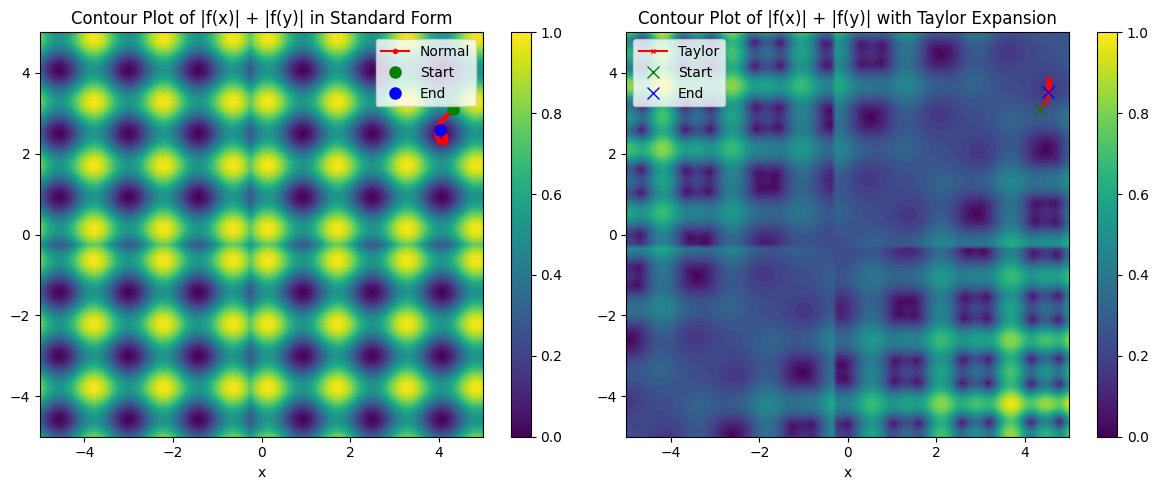

In [ ]:
## PLot the two contrours side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

Z_normal = norm_f(X, Y)
Z_taylor = jax.vmap(jax.vmap(norm_f_taylor, in_axes=(0,0)), in_axes=(0,0))(X, Y)

ax1.contourf(X, Y, Z_normal, levels=50)
ax1.set_title('Contour Plot of |f(x)| + |f(y)| in Standard Form')
ax1.set_xlabel('x')
ax1.plot(trajectory[:, 0], trajectory[:, 1], 'ro-', linewidth=1.5, markersize=3, label="Normal")
ax1.plot(trajectory[0, 0], trajectory[0, 1], 'go', label='Start', markersize=8)
ax1.plot(trajectory[-1, 0], trajectory[-1, 1], 'bo', label='End', markersize=8)
ax1.legend()
cbar1 = fig.colorbar(ax1.collections[0], ax=ax1)


ax2.contourf(X, Y, Z_taylor, levels=50)
ax2.set_title('Contour Plot of |f(x)| + |f(y)| with Taylor Expansion')
ax2.set_xlabel('x')
ax2.plot(trajectory_taylor[:, 0], trajectory_taylor[:, 1], 'rx-', linewidth=1.5, markersize=3, label="Taylor")
ax2.plot(trajectory_taylor[0, 0], trajectory_taylor[0, 1], 'gx', label='Start', markersize=8)
ax2.plot(trajectory_taylor[-1, 0], trajectory_taylor[-1, 1], 'bx', label='End', markersize=8)
ax2.legend()
cbar2 = fig.colorbar(ax2.collections[0], ax=ax2)

plt.tight_layout()
plt.draw()

plt.savefig("along_diagonal.png")


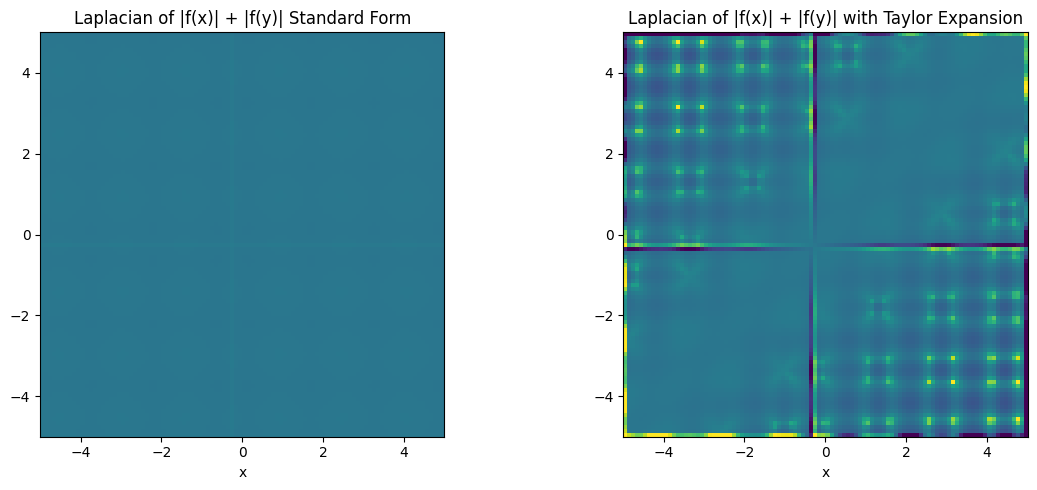

In [ ]:
## Plot the laplacian of Z approximated with finite difference - Trace of the Hessian

def laplacian2D(a, dx=1):
    # a_nn | a_nz | a_np
    # a_zn | a    | a_zp
    # a_pn | a_pz | a_pp
    a_zz = a

    a_nz = jnp.roll(a_zz, (+1, 0), (0, 1))
    a_pz = jnp.roll(a_zz, (-1, 0), (0, 1))
    a_zn = jnp.roll(a_zz, (0, +1), (0, 1))
    a_zp = jnp.roll(a_zz, (0, -1), (0, 1))

    a_nn = jnp.roll(a_zz, (+1, +1), (0, 1))
    a_np = jnp.roll(a_zz, (+1, -1), (0, 1))
    a_pn = jnp.roll(a_zz, (-1, +1), (0, 1))
    a_pp = jnp.roll(a_zz, (-1, -1), (0, 1))

    return (- 3 * a + 0.5 * (a_nz + a_pz + a_zn + a_zp) + 0.25 * (a_nn + a_np + a_pn + a_pp)) / (dx ** 2)

Z_lap = laplacian2D(Z_normal, dx=1)
Z_taylor_lap = laplacian2D(Z_taylor, dx=1)

vmin, vmax = Z_taylor_lap[5:-5,5:-5].min(), Z_taylor_lap[5:-5,5:-5].max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(Z_lap, cmap='viridis', extent=[-domain_x, domain_x, -domain_y, domain_y], vmin=vmin, vmax=vmax, origin='lower')
ax1.set_title('Laplacian of |f(x)| + |f(y)| Standard Form')
ax1.set_xlabel('x')
# cbar1 = fig.colorbar(ax1.collections[0], ax=ax1)
# cbar1.set_label('Norm of f(x, y)')

ax2.imshow(Z_taylor_lap, cmap='viridis', extent=[-domain_x, domain_x, -domain_y, domain_y], vmin=vmin, vmax=vmax, origin='lower')
ax2.set_title('Laplacian of |f(x)| + |f(y)| with Taylor Expansion')
ax2.set_xlabel('x')

#colorbars
# cbar2 = fig.colorbar(ax2.collections[0], ax=ax2)
# cbar2.set_label('Norm of f(x, y)')

plt.tight_layout()
plt.show()

In [ ]:
# %timeit -r10 -n20 gradient_descent(learning_rate, num_iterations, grad_norm_f).block_until_ready()
# %timeit -r10 -n20 gradient_descent(learning_rate, num_iterations, grad_norm_f_taylor).block_until_ready()